AI Project Flower classification


In [3]:
import tensorflow_datasets as tfds

dataset, info = tfds.load('tf_flowers', with_info=True, as_supervised=True)
print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.BSSVOT_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_dir='/root/tensorflow_datasets/tf_flowers/3.0.1',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Team",
    title = "Flowers",
    month = "jan",
    year = "2019",
    url = "http://download.ten

In [4]:
print("Classes:", info.features['label'].names)
print("Total images:", info.splits['train'].num_examples)

Classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Total images: 3670


In [5]:
import tensorflow as tf

# Load with split percentages
(train_ds, val_ds, test_ds) = tfds.load(
    'tf_flowers',
    split=['train[:70%]', 'train[70%:90%]', 'train[90%:]'],
    as_supervised=True
)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

# Apply preprocessing
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

class_names = ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

print("✅ Train:", len(list(train_ds)), "batches")
print("✅ Val:", len(list(val_ds)), "batches")
print("✅ Test:", len(list(test_ds)), "batches")
print("🎉 Data ready for training!")

✅ Train: 81 batches
✅ Val: 23 batches
✅ Test: 12 batches
🎉 Data ready for training!


In [6]:
import time
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Build ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze base (transfer learning)

model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

# Train
print("\n🚀 Training ResNet50...")
start = time.time()

history_resnet = model_resnet.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    verbose=1
)

resnet_time = time.time() - start
print(f"\n✅ ResNet50 done! Training time: {resnet_time/60:.1f} minutes")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


🚀 Training ResNet50...
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 38s 283ms/step - accuracy: 0.2947 - loss: 1.5855 - val_accuracy: 0.3733 - val_loss: 1.4538
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - accuracy: 0.3605 - loss: 1.4905 - val_accuracy: 0.3937 - val_loss: 1.4452
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.3760 - loss: 1.4744 - val_accuracy: 0.4046 - val_loss: 1.4324
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.3877 - loss: 1.4562 - val_accuracy: 0.4237 - val_loss: 1.3960
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.3967 - loss: 1.4396 - val_accuracy: 0.4223 - val_loss: 1.3819
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.4072 - loss: 1.4329 - val_accuracy: 0.4482 - val_loss: 1.3791
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.4142 - loss: 1.4166 - val_accuracy: 0.4332 - val_loss: 1.3728
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.4165 - l

In [7]:
from tensorflow.keras.applications import DenseNet121

# Build DenseNet121 model
base_model2 = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model2.trainable = False  # freeze base (transfer learning)

model_densenet = models.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_densenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_densenet.summary()

# Train
print("\n🚀 Training DenseNet121...")
start = time.time()

history_densenet = model_densenet.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    verbose=1
)

densenet_time = time.time() - start
print(f"\n✅ DenseNet121 done! Training time: {densenet_time/60:.1f} minutes")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,189 (27.85 MB)

 Trainable params: 263,685 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)


🚀 Training DenseNet121...
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 75s 589ms/step - accuracy: 0.7587 - loss: 0.6400 - val_accuracy: 0.8856 - val_loss: 0.3067
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.8918 - loss: 0.2974 - val_accuracy: 0.8992 - val_loss: 0.2610
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.9062 - loss: 0.2606 - val_accuracy: 0.8978 - val_loss: 0.2572
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.9260 - loss: 0.2048 - val_accuracy: 0.8896 - val_loss: 0.2700
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.9416 - loss: 0.1653 - val_accuracy: 0.8924 - val_loss: 0.2704
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.9541 - loss: 0.1284 - val_accuracy: 0.9019 - val_loss: 0.2615
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.9657 - loss: 0.1114 - val_accuracy: 0.8951 - val_loss: 0.2703
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.9689 - los

In [8]:
from tensorflow.keras.applications import MobileNetV3Small

# Build MobileNetV3 model
base_model3 = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model3.trainable = False  # freeze base (transfer learning)

model_mobilenet = models.Sequential([
    base_model3,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model_mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mobilenet.summary()

# Train
print("\n🚀 Training MobileNetV3...")
start = time.time()

history_mobilenet = model_mobilenet.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    verbose=1
)

mobilenet_time = time.time() - start
print(f"\n✅ MobileNetV3 done! Training time: {mobilenet_time/60:.1f} minutes")


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,117 (4.15 MB)

 Trainable params: 148,997 (582.02 KB)

 Non-trainable params: 939,120 (3.58 MB)


🚀 Training MobileNetV3...
Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 35s 270ms/step - accuracy: 0.2569 - loss: 1.6090 - val_accuracy: 0.3025 - val_loss: 1.5721
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.2888 - loss: 1.5763 - val_accuracy: 0.3079 - val_loss: 1.5632
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2927 - loss: 1.5631 - val_accuracy: 0.3093 - val_loss: 1.5590
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3017 - loss: 1.5553 - val_accuracy: 0.3202 - val_loss: 1.5475
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.3114 - loss: 1.5495 - val_accuracy: 0.3215 - val_loss: 1.5347
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3122 - loss: 1.5459 - val_accuracy: 0.3215 - val_loss: 1.5353
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3145 - loss: 1.5414 - val_accuracy: 0.3297 - val_loss: 1.5339
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3235 - loss: 1.53

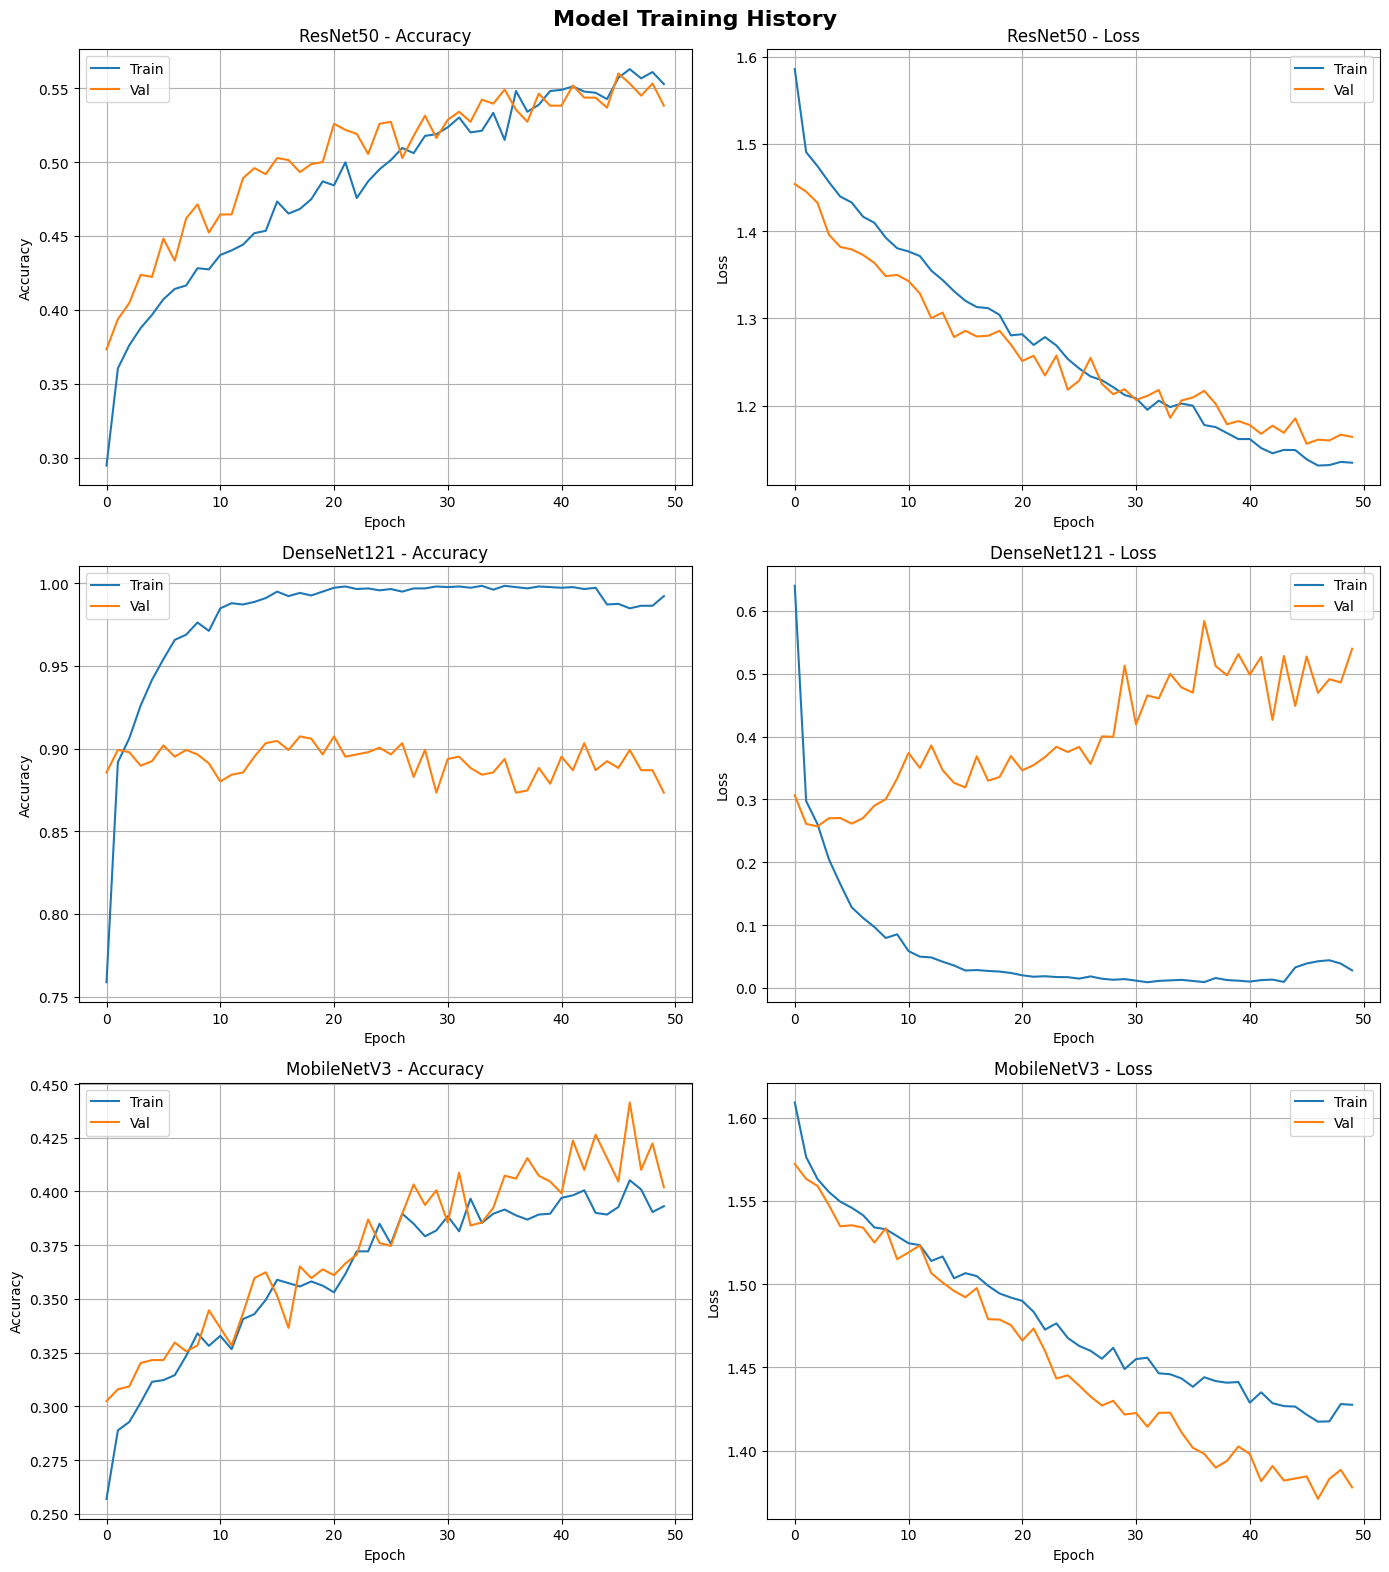

✅ Training curves saved!


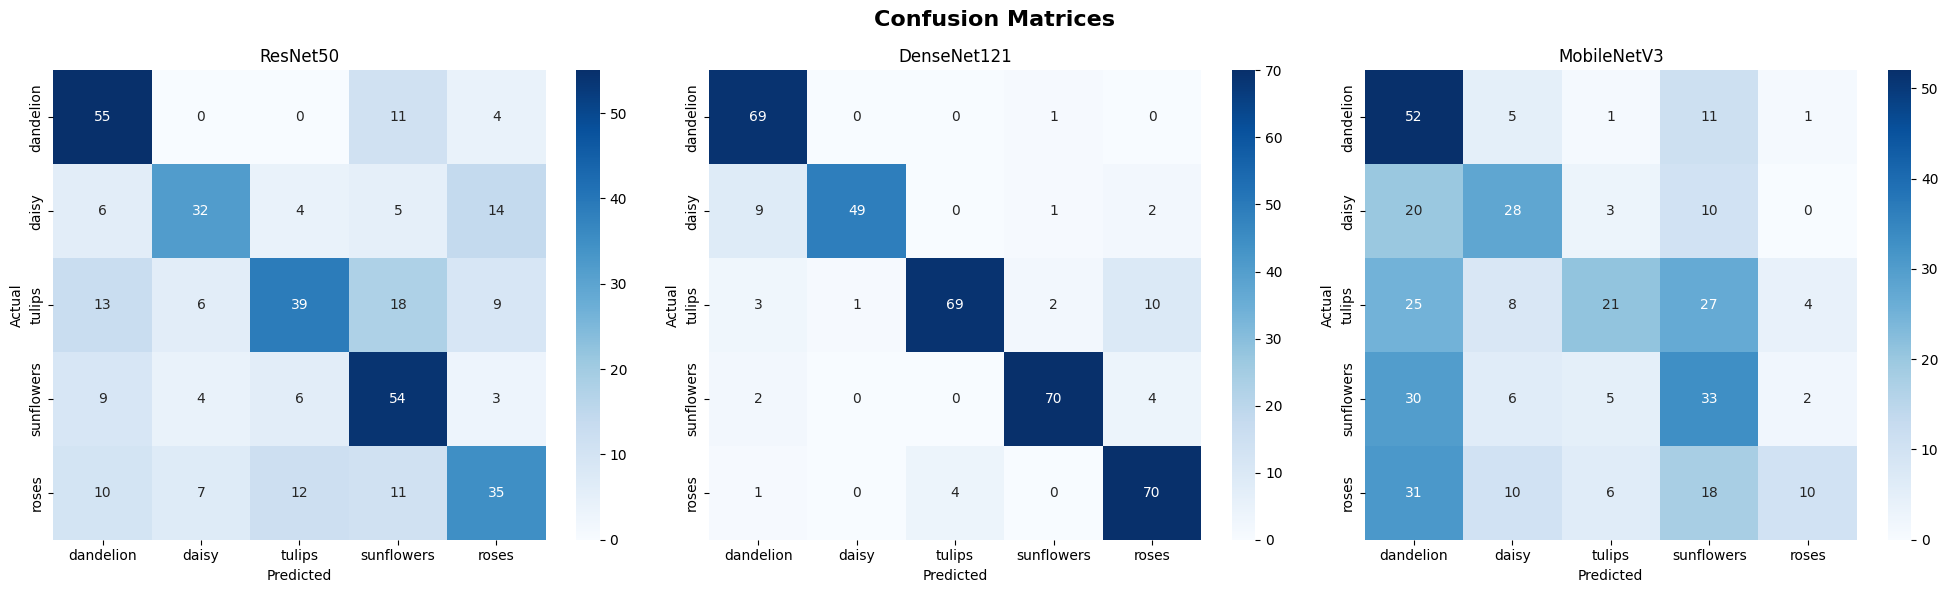

✅ Confusion matrices saved!


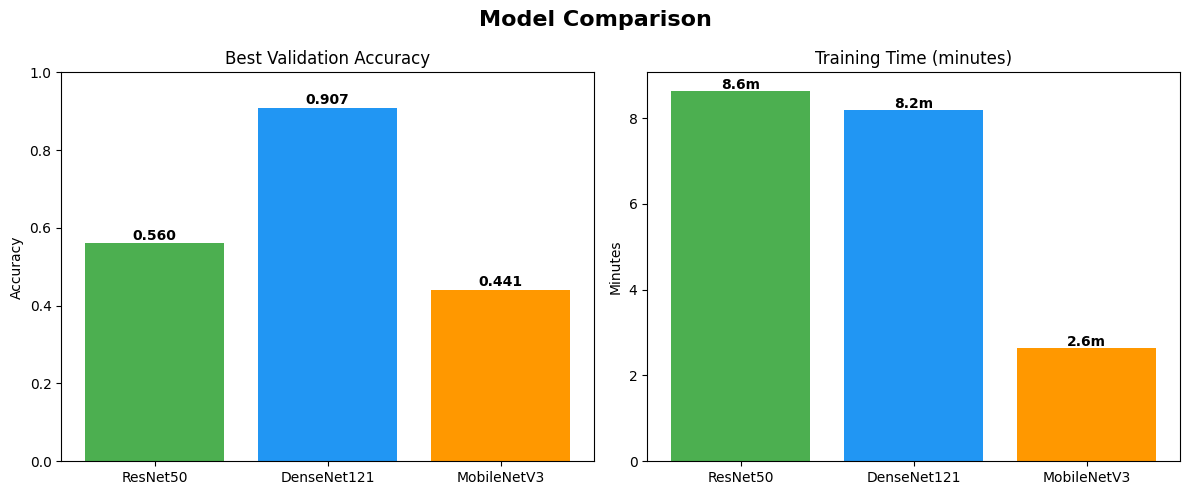

✅ Comparison chart saved!

📊 FINAL RESULTS SUMMARY
═══════════════════════════════════
ResNet50     → Accuracy: 0.560 | Time: 8.6 min
DenseNet121  → Accuracy: 0.907 | Time: 8.2 min
MobileNetV3  → Accuracy: 0.441 | Time: 2.6 min
═══════════════════════════════════



In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

# ── 1. Loss & Accuracy Curves ──────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Model Training History', fontsize=16, fontweight='bold')

histories = [
    (history_resnet, 'ResNet50'),
    (history_densenet, 'DenseNet121'),
    (history_mobilenet, 'MobileNetV3')
]

for i, (history, name) in enumerate(histories):
    # Accuracy
    axes[i, 0].plot(history.history['accuracy'], label='Train')
    axes[i, 0].plot(history.history['val_accuracy'], label='Val')
    axes[i, 0].set_title(f'{name} - Accuracy')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Accuracy')
    axes[i, 0].legend()
    axes[i, 0].grid(True)

    # Loss
    axes[i, 1].plot(history.history['loss'], label='Train')
    axes[i, 1].plot(history.history['val_loss'], label='Val')
    axes[i, 1].set_title(f'{name} - Loss')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Loss')
    axes[i, 1].legend()
    axes[i, 1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("✅ Training curves saved!")

# ── 2. Confusion Matrices ───────────────────────────────────────────────
models_list = [
    (model_resnet, 'ResNet50'),
    (model_densenet, 'DenseNet121'),
    (model_mobilenet, 'MobileNetV3')
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for ax, (model, name) in zip(axes, models_list):
    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion matrices saved!")

# ── 3. Final Comparison Bar Chart ──────────────────────────────────────
resnet_acc = max(history_resnet.history['val_accuracy'])
densenet_acc = max(history_densenet.history['val_accuracy'])
mobilenet_acc = max(history_mobilenet.history['val_accuracy'])

model_names = ['ResNet50', 'DenseNet121', 'MobileNetV3']
accuracies = [resnet_acc, densenet_acc, mobilenet_acc]
times = [resnet_time/60, densenet_time/60, mobilenet_time/60]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

# Accuracy comparison
bars1 = axes[0].bar(model_names, accuracies, color=['#4CAF50', '#2196F3', '#FF9800'])
axes[0].set_title('Best Validation Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', fontweight='bold')

# Training time comparison
bars2 = axes[1].bar(model_names, times, color=['#4CAF50', '#2196F3', '#FF9800'])
axes[1].set_title('Training Time (minutes)')
axes[1].set_ylabel('Minutes')
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{t:.1f}m', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("✅ Comparison chart saved!")

print(f"""
📊 FINAL RESULTS SUMMARY
═══════════════════════════════════
ResNet50     → Accuracy: {resnet_acc:.3f} | Time: {resnet_time/60:.1f} min
DenseNet121  → Accuracy: {densenet_acc:.3f} | Time: {densenet_time/60:.1f} min
MobileNetV3  → Accuracy: {mobilenet_acc:.3f} | Time: {mobilenet_time/60:.1f} min
═══════════════════════════════════
""")

In [10]:
from sklearn.metrics import average_precision_score
import numpy as np

for model, name in [(model_resnet,'ResNet50'),(model_densenet,'DenseNet121'),(model_mobilenet,'MobileNetV3')]:
    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(preds)
        y_true.extend(labels.numpy())
    mAP = average_precision_score(np.array(y_true), np.array(y_pred), average='macro')
    print(f"{name} mAP: {mAP:.3f}")

ResNet50 mAP: 0.627
DenseNet121 mAP: 0.976
MobileNetV3 mAP: 0.423
